# 🎯 ViT-Base - Plant Disease Classification

**Model:** Vision Transformer Base (ViT-Base-16)

**Expected Performance:**
- PlantVillage (validation): ~99%
- PlantDoc (test): ~74% F1 (from paper)

**Configuration:**
- Pretrained on ImageNet-21k
- Fine-tuned with domain adaptation
- 384x384 images (higher res for ViT)
- 15 epochs with early stopping

---

## ⚠️ Enable GPU First!
**Runtime → Change runtime type → T4 GPU → Save**

In [1]:
# Check GPU
import torch
print(f"GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ NO GPU! Enable GPU in Runtime settings.")

GPU: True
Device: Tesla T4


In [2]:
!pip install -q timm albumentations scikit-learn opendatasets
print("✅ Installed")

✅ Installed


In [3]:
# Download datasets
import os, opendatasets as od

if not os.path.exists('/content/plantvillage'):
    print("📥 Downloading PlantVillage...")
    od.download("https://www.kaggle.com/datasets/mohitsingh1804/plantvillage")

if not os.path.exists('/content/PlantDoc-Dataset'):
    print("📥 Downloading PlantDoc...")
    !git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

print("✅ Datasets ready")

📥 Downloading PlantVillage...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mohinarustamova
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage


100%|██████████| 818M/818M [00:04<00:00, 199MB/s] 



📥 Downloading PlantDoc...
Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 39.47 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
✅ Datasets ready


In [26]:
import os, random, numpy as np, pandas as pd, cv2, json, time, warnings
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Paths
pv_base = Path('/content/plantvillage/PlantVillage') if Path('/content/plantvillage/PlantVillage').exists() else Path('/content/plantvillage')
PV_TRAIN = pv_base / 'train'
PV_VAL = pv_base / 'val'
PD_TEST = Path('/content/PlantDoc-Dataset/test')

# Config
BATCH_SIZE = 32 # Smaller for ViT-Base (larger model)
EPOCHS = 10
LR = 1e-4
IMG_SIZE = 224  # Higher resolution for ViT
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(42); np.random.seed(42); torch.manual_seed(42)

In [27]:
# Labels
common_labels = sorted([
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___healthy", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Grape___healthy", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight",
    "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites_Two-spotted_spider_mite",
    "Tomato___Target_Spot", "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy"
])

plantdoc_to_plantvillage = {
    "Apple leaf": "Apple___healthy", "Apple rust leaf": "Apple___Cedar_apple_rust",
    "Apple Scab Leaf": "Apple___Apple_scab", "Bell_pepper leaf": "Pepper,_bell___healthy",
    "Bell_pepper leaf spot": "Pepper,_bell___Bacterial_spot", "Blueberry leaf": "Blueberry___healthy",
    "Cherry leaf": "Cherry_(including_sour)___healthy", "Corn Gray leaf spot": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn leaf blight": "Corn_(maize)___Northern_Leaf_Blight", "Corn rust leaf": "Corn_(maize)___Common_rust_",
    "Peach leaf": "Peach___healthy", "Potato leaf": "Potato___healthy",
    "Potato leaf early blight": "Potato___Early_blight", "Potato leaf late blight": "Potato___Late_blight",
    "Raspberry leaf": "Raspberry___healthy", "Soybean leaf": "Soybean___healthy",
    "Squash Powdery mildew leaf": "Squash___Powdery_mildew", "Strawberry leaf": "Strawberry___healthy",
    "Tomato Early blight leaf": "Tomato___Early_blight", "Tomato Septoria leaf spot": "Tomato___Septoria_leaf_spot",
    "Tomato leaf": "Tomato___healthy", "Tomato leaf bacterial spot": "Tomato___Bacterial_spot",
    "Tomato leaf late blight": "Tomato___Late_blight", "Tomato leaf mosaic virus": "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato mold leaf": "Tomato___Leaf_Mold",
    "Tomato two spotted spider mites leaf": "Tomato___Spider_mites_Two-spotted_spider_mite",
    "grape leaf": "Grape___healthy", "grape leaf black rot": "Apple___Black_rot"
}

label2idx = {l: i for i, l in enumerate(common_labels)}
num_classes = len(common_labels)
print(f"Classes: {num_classes}")

Classes: 30


In [28]:
# Dataset with augmentation
class Augmentation:
    def __init__(self, img_size=224, is_train=False):
        if is_train:
            self.t = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2()
            ])
        else:
            self.t = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2()
            ])
    def __call__(self, img):
        return self.t(image=np.array(img) if isinstance(img, Image.Image) else img)['image']

class PVDataset(Dataset):
    def __init__(self, root, l2i, size=384, is_train=False):
        self.t = Augmentation(size, is_train)
        self.samples = [(str(p), l2i[l]) for l in l2i for ext in ['*.jpg','*.JPG','*.png']
                       for p in (Path(root)/l).glob(ext) if (Path(root)/l).exists()]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.t(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)), l

class PDDataset(Dataset):
    def __init__(self, root, l2i, pd2pv, size=384):
        self.t = Augmentation(size, is_train=False)
        self.samples = [(str(p), l2i[pv]) for pd, pv in pd2pv.items() if pv in l2i
                       for ext in ['*.jpg','*.JPG','*.png'] for p in (Path(root)/pd).glob(ext)
                       if (Path(root)/pd).exists()]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.t(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)), l

In [29]:
# Load data
trn = PVDataset(str(PV_TRAIN), label2idx, IMG_SIZE, is_train=True)
val = PVDataset(str(PV_VAL), label2idx, IMG_SIZE, is_train=False)
tst = PDDataset(str(PD_TEST), label2idx, plantdoc_to_plantvillage, IMG_SIZE)

trn_l = DataLoader(trn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_l = DataLoader(val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
tst_l = DataLoader(tst, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(trn):,} | Val: {len(val):,} | Test: {len(tst):,}")

Train: 30,766 | Val: 7,692 | Test: 228


In [30]:
# Model
print("Loading ViT-Base-16-224...")
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
model = model.to(DEVICE)
print(f"✅ Model loaded on {DEVICE}")

Loading ViT-Base-16-224...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Model loaded on cuda


In [31]:
# Training functions
def train_epoch(m, loader, crit, opt, dev):
    m.train(); loss_sum, corr, tot = 0, 0, 0
    for img, lbl in tqdm(loader, desc='Train', leave=False):
        img, lbl = img.to(dev), lbl.to(dev)
        opt.zero_grad(); out = m(img); loss = crit(out, lbl)
        loss.backward(); opt.step()
        loss_sum += loss.item(); tot += lbl.size(0)
        corr += out.max(1)[1].eq(lbl).sum().item()
    return loss_sum/len(loader), 100.*corr/tot

def evaluate(m, loader, crit, dev):
    m.eval(); loss_sum, preds, labels = 0, [], []
    with torch.no_grad():
        for img, lbl in tqdm(loader, desc='Eval', leave=False):
            img, lbl = img.to(dev), lbl.to(dev)
            out = m(img); loss_sum += crit(out, lbl).item()
            preds.extend(out.max(1)[1].cpu().numpy())
            labels.extend(lbl.cpu().numpy())
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    return {'loss': loss_sum/len(loader), 'acc': acc*100, 'f1': f1*100, 'precision': p*100, 'recall': r*100}

In [32]:
# Train
print("\n" + "="*60)
print("Training ViT-Base")
print("="*60 + "\n")

crit = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

best_f1, patience_counter = 0, 0
t0 = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    tl, ta = train_epoch(model, trn_l, crit, opt, DEVICE)
    v = evaluate(model, val_l, crit, DEVICE)
    sch.step(v['f1'])

    print(f"Loss: {tl:.4f} | Train Acc: {ta:.2f}% | Val F1: {v['f1']:.2f}%")

    if v['f1'] > best_f1:
        best_f1 = v['f1']; patience_counter = 0
        torch.save(model.state_dict(), '/content/vit_base_best.pth')
        print(f"✓ Best F1: {best_f1:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print(f"Early stop"); break

# Test
model.load_state_dict(torch.load('/content/vit_base_best.pth'))
test = evaluate(model, tst_l, crit, DEVICE)
training_time = time.time() - t0

print(f"\n{'='*60}")
print("FINAL RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test['acc']:.2f}%")
print(f"Test F1: {test['f1']:.2f}%")
print(f"Test Precision: {test['precision']:.2f}%")
print(f"Test Recall: {test['recall']:.2f}%")
print(f"Training Time: {training_time/60:.1f} min")
print(f"{'='*60}")


Training ViT-Base


Epoch 1/10


Train:   0%|          | 0/962 [00:00<?, ?it/s]

Eval:   0%|          | 0/241 [00:00<?, ?it/s]

Loss: 0.1821 | Train Acc: 94.60% | Val F1: 98.57%
✓ Best F1: 98.57%

Epoch 2/10


Train:   0%|          | 0/962 [00:00<?, ?it/s]

...

Train:   0%|          | 0/962 [00:00<?, ?it/s]

Eval:   0%|          | 0/241 [00:00<?, ?it/s]

Loss: 0.0068 | Train Acc: 99.80% | Val F1: 98.85%


Eval:   0%|          | 0/8 [00:00<?, ?it/s]


FINAL RESULTS
Test Accuracy: 23.25%
Test F1: 19.78%
Test Precision: 24.83%
Test Recall: 23.25%
Training Time: 191.2 min


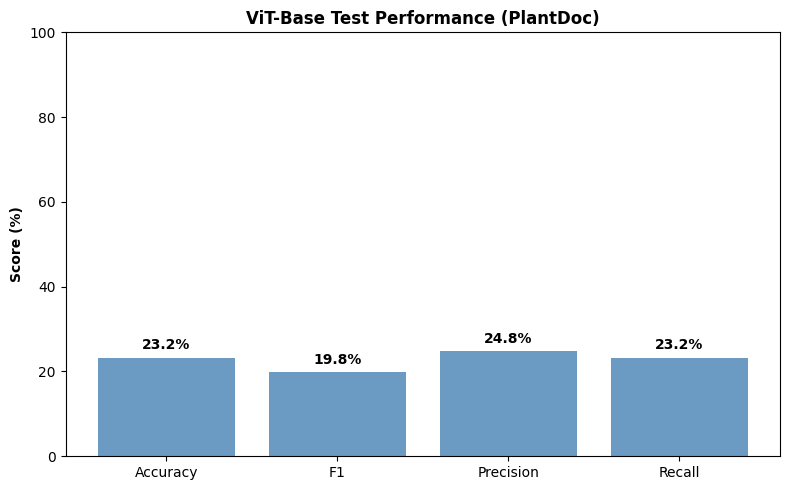


✅ Saved:
   • vit_base_best.pth
   • vit_base_results.json
   • vit_base_results.png


In [34]:
# Save results
results = {
    'model': 'ViT-Base-16-224',
    'test_acc': test['acc'],
    'test_f1': test['f1'],
    'test_precision': test['precision'],
    'test_recall': test['recall'],
    'best_val_f1': best_f1,
    'time_minutes': training_time/60
}

import json
with open('/content/vit_base_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Simple visualization
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
values = [test['acc'], test['f1'], test['precision'], test['recall']]
ax.bar(metrics, values, color='steelblue', alpha=0.8)
ax.set_ylabel('Score (%)', fontweight='bold')
ax.set_title('ViT-Base Test Performance (PlantDoc)', fontweight='bold')
ax.set_ylim([0, 100])
for i, v in enumerate(values):
    ax.text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/vit_base_results.png', dpi=300)
plt.show()

print("\n✅ Saved:")
print("   • vit_base_best.pth")
print("   • vit_base_results.json")
print("   • vit_base_results.png")

In [35]:
# Download
from google.colab import files
files.download('/content/vit_base_results.json')
files.download('/content/vit_base_results.png')
print("✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!
